# Who's really choking Delhi: Diwali crackers or Punjab's stubble fires?

Every November, Delhi's air becomes some of the worst on Earth, and every November the same argument
starts: is it the **firecrackers** of Diwali, or the **crop-residue fires** in Punjab and Haryana?

This notebook tests both with five seasons of measured air-quality data (2015–2019), over 600,000 NASA
satellite fire detections and hourly weather reanalysis.

**Short answer:**
1. **Diwali night** is one of the five most polluted nights of every year (hourly PM2.5 of 500–800 µg/m³),
   but the spike is short. Over the season it adds roughly 2% as much pollution as the stubble-burning period.
2. **Stubble-season smoke** is the main driver in the first half of November: about **60%** of the
   PM2.5 Delhi breathes from 1–10 November, and about **40%** from mid-October to the end of November.
3. **Over the whole winter**, Delhi's own pollution trapped by winter weather is the biggest share,
   at roughly **80–90%**. That's why December and January stay toxic long after the fires stop.

Data sources: CPCB station data (via Kaggle), NASA FIRMS VIIRS fire detections and Open-Meteo ERA5 weather.
Run `python src/fetch_data.py && python src/prepare_data.py` first.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from matplotlib import patheffects
from matplotlib.colors import LogNorm
from matplotlib.ticker import StrMethodFormatter
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

# the notebook is in the notebooks/ folder, so the project folder is one level up
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# my chart colours and helpers (titles, footnote, save) are in src/style.py
sys.path.append(str(ROOT / "src"))
from style import BLUE, BLUE_LIGHT, INK, INK_2, NEUTRAL, ORANGE, ORANGE_LIGHT, VIOLET, footnote, save, titles

PROC = ROOT / "data" / "processed"     # the tables made by src/prepare_data.py
pd.set_option("display.precision", 1)

pm = pd.read_csv(PROC / "pm25_daily.csv", parse_dates=["date"])
weather = pd.read_csv(PROC / "weather_daily.csv", parse_dates=["date"])
fires = pd.read_csv(PROC / "fires_daily.csv", parse_dates=["date"])
hourly = pd.read_csv(PROC / "pm25_hourly.csv", parse_dates=["datetime"])

# one row per day: PM2.5, the weather, and the fire count
daily = pm.merge(weather, on="date")
daily = daily.merge(fires, on="date", how="left")

# a "season" runs July to June, so October 2018 – March 2019 is season 2018
daily["season"] = np.where(daily["date"].dt.month >= 7, daily["date"].dt.year, daily["date"].dt.year - 1)
daily["md"] = daily["date"].dt.month * 100 + daily["date"].dt.day     # month-day, e.g. 1105 = 5 Nov
daily["dow"] = daily["date"].dt.dayofweek                             # day of the week
daily["lmix"] = np.log(daily["mixing_height_m"])                      # afternoon mixing height (log)
daily["lnight"] = np.log(daily["night_mixing_m"])                     # night-time mixing height (log)

DIWALI = pd.to_datetime(["2015-11-11", "2016-10-30", "2017-10-19", "2018-11-07", "2019-10-27"])
SEASONS = range(2015, 2020)

first_day = daily["date"].min()
last_day = daily["date"].max()
print(f"{len(daily):,} days of PM2.5 + weather, {first_day:%b %Y} – {last_day:%b %Y}")
print(f"{fires['fire_count'].sum():,.0f} fire detections in Punjab + Haryana, 2015–2025")

2,009 days of PM2.5 + weather, Jan 2015 – Jul 2020
618,285 fire detections in Punjab + Haryana, 2015–2025


## 1. The fires

NASA's VIIRS satellite instrument flags every hot spot it sees in Punjab and Haryana. Burning peaks
from late October to mid-November, between the rice harvest and wheat sowing.

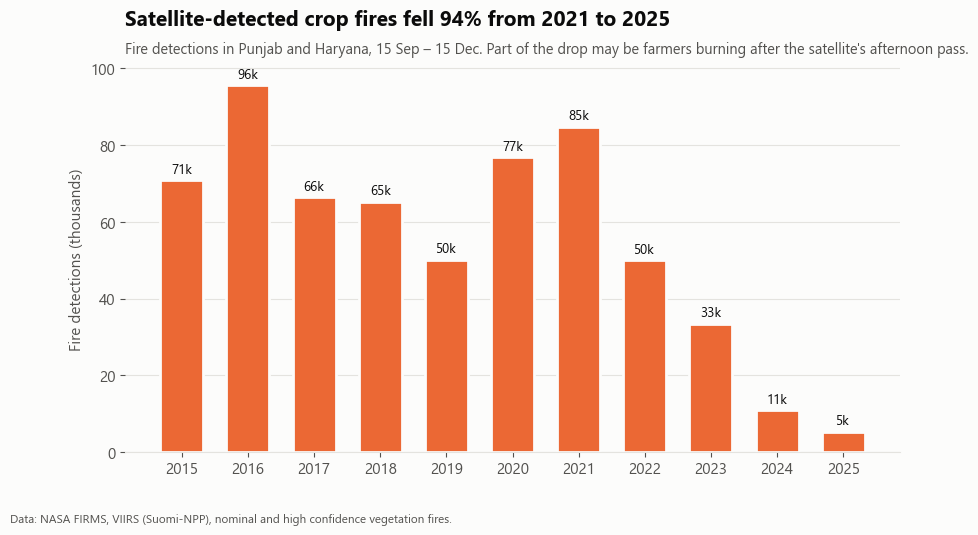

In [2]:
# Chart 1: fires detected each burning season (15 Sep – 15 Dec)
month_day = fires["date"].dt.month * 100 + fires["date"].dt.day
season_rows = fires[(month_day >= 915) & (month_day <= 1215)]
season_fires = season_rows.groupby(season_rows["date"].dt.year)["fire_count"].sum()

bar_labels = []
for value in season_fires.values:
    bar_labels.append(f"{value / 1000:.0f}k")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(season_fires.index, season_fires.values / 1000, color=ORANGE, width=0.65, edgecolor="#fcfcfb",
              linewidth=2)
ax.bar_label(bars, labels=bar_labels, padding=3, fontsize=9.5)
ax.set_xticks(season_fires.index)
ax.set_ylabel("Fire detections (thousands)")
ax.grid(axis="x", visible=False)
drop = 1 - season_fires[2025] / season_fires[2021]
titles(ax, f"Satellite-detected crop fires fell {drop:.0%} from 2021 to 2025",
       "Fire detections in Punjab and Haryana, 15 Sep – 15 Dec. Part of the drop may be farmers burning after the satellite's afternoon pass.")
footnote(fig, "Data: NASA FIRMS, VIIRS (Suomi-NPP), nominal and high confidence vegetation fires.", y=-0.03)
save(fig, "01_fires_by_year.png")
plt.show()

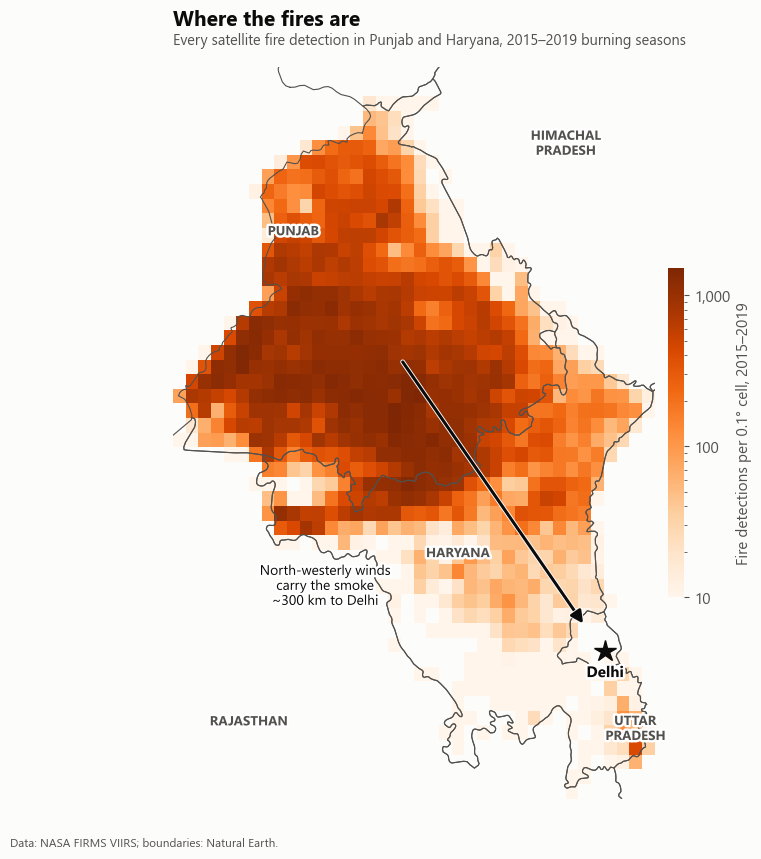

In [3]:
# Chart 2: map of where the fires are, on a 0.1-degree grid
geojson = json.loads((ROOT / "data/raw/north_india_states.geojson").read_text())

grid = pd.read_csv(PROC / "fires_grid.csv")
grid = grid[(grid["year"] >= 2015) & (grid["year"] <= 2019)]
grid = grid.groupby(["lat", "lon"])["fires"].sum().reset_index()

# the edges of the grid cells
lons = np.round(np.arange(73.8, 77.65, 0.1), 2)
lats = np.round(np.arange(27.6, 32.65, 0.1), 2)

# count the fires in each cell
counts = np.zeros((len(lats) - 1, len(lons) - 1))
for _, cell in grid.iterrows():
    row = int((cell["lat"] - 27.6) // 0.1)
    column = int((cell["lon"] - 73.8) // 0.1)
    if 0 <= row < counts.shape[0] and 0 <= column < counts.shape[1]:
        counts[row, column] += cell["fires"]

fig, ax = plt.subplots(figsize=(8.5, 9.5))
empty_cells_hidden = np.ma.masked_equal(counts, 0)
mesh = ax.pcolormesh(lons, lats, empty_cells_hidden, cmap="Oranges", norm=LogNorm(vmin=10, vmax=counts.max()))

# state borders
for feature in geojson["features"]:
    geometry = feature["geometry"]
    if geometry["type"] == "MultiPolygon":
        polygons = geometry["coordinates"]
    else:
        polygons = [geometry["coordinates"]]
    for polygon in polygons:
        outline = np.array(polygon[0])        # the outer ring of the polygon
        ax.plot(outline[:, 0], outline[:, 1], color=INK_2, lw=0.8)

# a white outline around the text keeps it readable over the fire cells
halo = [patheffects.withStroke(linewidth=3.5, foreground="white")]
state_labels = [
    ("PUNJAB", 74.75, 31.45),
    ("HARYANA", 76.05, 29.25),
    ("RAJASTHAN", 74.4, 28.1),
    ("HIMACHAL\nPRADESH", 76.9, 32.0),
    ("UTTAR\nPRADESH", 77.45, 28.0),
]
for name, x, y in state_labels:
    ax.text(x, y, name, color=INK_2, fontsize=9.5, ha="center", fontweight="bold", path_effects=halo, zorder=6)

ax.plot(77.21, 28.61, marker="*", ms=16, color=INK, zorder=5)
ax.text(77.21, 28.43, "Delhi", ha="center", fontsize=11, fontweight="bold", path_effects=halo, zorder=6)
ax.annotate("", xy=(77.05, 28.78), xytext=(75.6, 30.6),
            arrowprops=dict(arrowstyle="-|>", color=INK, lw=2.2, mutation_scale=18, path_effects=halo), zorder=6)
ax.text(75.0, 29.05, "North-westerly winds\ncarry the smoke\n~300 km to Delhi", fontsize=10, ha="center",
        va="center", path_effects=halo, zorder=6)

ax.set_xlim(73.8, 77.6)
ax.set_ylim(27.6, 32.6)
ax.set_aspect(1 / np.cos(np.deg2rad(30)))      # so 1 degree east looks as long as it really is at 30°N
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(False)

colourbar = fig.colorbar(mesh, ax=ax, shrink=0.45, pad=0.02)
colourbar.set_label("Fire detections per 0.1° cell, 2015–2019", color=INK_2)
colourbar.ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
colourbar.outline.set_visible(False)
titles(ax, "Where the fires are", "Every satellite fire detection in Punjab and Haryana, 2015–2019 burning seasons")
footnote(fig, "Data: NASA FIRMS VIIRS; boundaries: Natural Earth.", y=0.06)
save(fig, "02_fire_map.png")
plt.show()

## 2. Why a simple correlation misleads

The obvious approach is to regress Delhi's daily PM2.5 on the number of fires. That gives a large, highly
"significant" fire effect. The **placebo test** below gives the model the *wrong year's* fires (same
calendar dates, previous or next year). Fake fires "explain" pollution just as well as real ones.

The reason is that fires and smog both peak in November, partly because November weather traps
pollution. Daily fire counts can't separate the smoke from the season, so a different method is needed.

In [4]:
fire_by_date = fires.set_index("date")["fire_count"]


def fires_around(dates, year_shift=0):
    """Average fires on day t and day t-1 (smoke takes about a day to arrive), in thousands.

    year_shift=1 looks up the same dates one year earlier, -1 one year later (the placebo tests).
    """
    values = []
    for day in dates:
        today = fire_by_date.get(day - pd.DateOffset(years=year_shift), np.nan)
        yesterday = fire_by_date.get(day - pd.Timedelta(days=1) - pd.DateOffset(years=year_shift), np.nan)
        values.append((today + yesterday) / 2 / 1000)
    return values


# October and November of the five seasons
autumn = daily[(daily["md"] >= 1001) & (daily["md"] <= 1130) & daily["season"].isin(SEASONS)].copy()
autumn["diwali"] = autumn["date"].isin(DIWALI).astype(int)
autumn["diwali_next"] = autumn["date"].isin(DIWALI + pd.Timedelta(days=1)).astype(int)

# the real fires, and two placebos: the previous year's and the next year's fires on the same dates
variants = [
    ("f_real", "real fires", 0),
    ("f_prev", "placebo: previous year's fires", 1),
    ("f_next", "placebo: next year's fires", -1),
]
for column, label, shift in variants:
    autumn[column] = fires_around(autumn["date"], shift)
sample = autumn.dropna(subset=["f_real", "f_prev", "f_next"])

rows = []
for column, label, shift in variants:
    formula = f"pm25_city ~ {column} + diwali + diwali_next + lmix + wind_kmh + rain_mm + temp_c + C(season)"
    model = smf.ols(formula, data=sample).fit(cov_type="HAC", cov_kwds={"maxlags": 3})   # errors robust to autocorrelation
    interval = model.conf_int().loc[column]
    rows.append({
        "fire variable": label,
        "µg/m³ per 1,000 fires/day": model.params[column],
        "95% CI low": interval[0],
        "95% CI high": interval[1],
        "R²": model.rsquared,
    })
pd.DataFrame(rows).set_index("fire variable")

,"µg/m³ per 1,000 fires/day",95% CI low,95% CI high,R²
fire variable,,,,
real fires,35.9,20.1,51.7,0.4
placebo: previous year's fires,45.0,28.2,61.8,0.5
placebo: next year's fires,45.9,25.6,66.2,0.5


## 3. A better method: weather normalisation

Instead of asking *"do more fires mean more smog?"*, the question becomes *"how much worse is the air
than the weather alone would predict?"*

1. **Train a weather model on fire-free months.** From 16 December to 31 March there's almost no burning
   (about 1–2% of autumn's fire count), but Delhi's own emissions continue and winter weather traps them.
   A model fitted there learns how weather affects Delhi's own pollution.
2. **Predict October–November from the weather alone.** This is what the air would look like with
   Delhi's usual emissions under that season's weather.
3. **The gap between actual and predicted is the autumn excess.** That's pollution only autumn has:
   stubble smoke, plus Diwali.

The model is a log-linear regression on daily weather: afternoon and night mixing height (how high
pollution can disperse), wind speed and direction, temperature, diurnal range, humidity, rain, day of
week, and a separate level for each season. A gradient-boosting model was also tested. It did worse
out of sample (R² 0.25 against 0.43 when whole winters are held out), because ~600 training days aren't
enough for it.

In [5]:
WEATHER_TERMS = "wind_kmh + wind_u + wind_v + lmix + lnight + temp_c + temp_range_c + rh_pct + rain_mm + C(dow)"
covid = daily["date"] >= "2020-03-22"     # the lockdown changed emissions, so keep it out of training


def weather_model(y="pm25_city", train_mask=None, formula=None):
    """Fit log(PM2.5) ~ weather on the fire-free months (16 Dec – 31 Mar).

    Returns the model, the smearing factor and the training days. Smearing corrects for the fact that
    exp(average of the logs) underestimates the average.
    """
    if train_mask is None:
        train_mask = (daily["md"] >= 1216) | (daily["md"] <= 331)
    if formula is None:
        formula = f"np.log({y}) ~ {WEATHER_TERMS} + C(season)"
    train = daily[train_mask & ~covid & daily[y].notna()]
    model = smf.ols(formula, data=train).fit()
    smear = np.mean(np.exp(model.resid))
    return model, smear, train


model, smear, train = weather_model()

# cross-validation: hold out one month of one winter at a time, and predict it from the rest
cv_pred = pd.Series(index=train.index, dtype=float)
for _, block in train.groupby(["season", train["date"].dt.month]):
    rest = train.drop(block.index)
    cv_model = smf.ols(f"np.log(pm25_city) ~ {WEATHER_TERMS} + C(season)", data=rest).fit()
    cv_pred[block.index] = cv_model.predict(block)

cv_r2 = r2_score(np.log(train["pm25_city"]), cv_pred)
print(f"training days: {len(train)} | in-sample R² (log): {model.rsquared:.2f} | held-out-month R² (log): {cv_r2:.2f}")
afternoon_effect = 1 - 2 ** model.params["lmix"]       # effect of doubling the mixing height
night_effect = 1 - 2 ** model.params["lnight"]
print(f"doubling the afternoon mixing height cuts PM2.5 by {afternoon_effect:.0%}; "
      f"doubling night mixing height cuts it by a further {night_effect:.0%}")

# predict 1 October – 15 December from the weather alone; the gap is the autumn excess
season_window = daily[(daily["md"] >= 1001) & (daily["md"] <= 1215) & daily["season"].isin(SEASONS)].copy()
season_window["predicted"] = np.exp(model.predict(season_window)) * smear
season_window["excess"] = season_window["pm25_city"] - season_window["predicted"]

training days: 612 | in-sample R² (log): 0.58 | held-out-month R² (log): 0.42
doubling the afternoon mixing height cuts PM2.5 by 26%; doubling night mixing height cuts it by a further 18%


**Checks.** The excess should be close to zero *before* the burning starts (early October) and
*after* it ends (early December, a period the model never saw). It is: −7 and +20 µg/m³. In between
it rises and falls with the fires.

In [6]:
# average actual, predicted and excess PM2.5 in each 10-day window
windows = [("1–10 Oct", 1001, 1010), ("11–20 Oct", 1011, 1020), ("21–31 Oct", 1021, 1031), ("1–10 Nov", 1101, 1110),
           ("11–20 Nov", 1111, 1120), ("21–30 Nov", 1121, 1130), ("1–15 Dec", 1201, 1215)]
rows = []
for name, start, end in windows:
    days = season_window[(season_window["md"] >= start) & (season_window["md"] <= end)]
    excess_share = days["excess"].mean() / days["pm25_city"].mean()
    rows.append({
        "period": name,
        "actual PM2.5": days["pm25_city"].mean(),
        "weather-only prediction": days["predicted"].mean(),
        "autumn excess": days["excess"].mean(),
        "excess share": f"{excess_share:.0%}",
        "fires per day": days["fire_count"].mean(),
    })
check = pd.DataFrame(rows).set_index("period")
check

,actual PM2.5,weather-only prediction,autumn excess,excess share,fires per day
period,,,,,
1–10 Oct,95.7,102.4,-6.7,-7%,163.5
11–20 Oct,130.7,103.7,27.0,21%,625.8
21–31 Oct,191.3,108.9,82.4,43%,1783.4
1–10 Nov,298.8,121.2,177.6,59%,2914.3
11–20 Nov,234.6,128.9,105.7,45%,1015.7
21–30 Nov,181.3,150.2,31.2,17%,216.4
1–15 Dec,194.2,174.0,20.2,10%,24.3


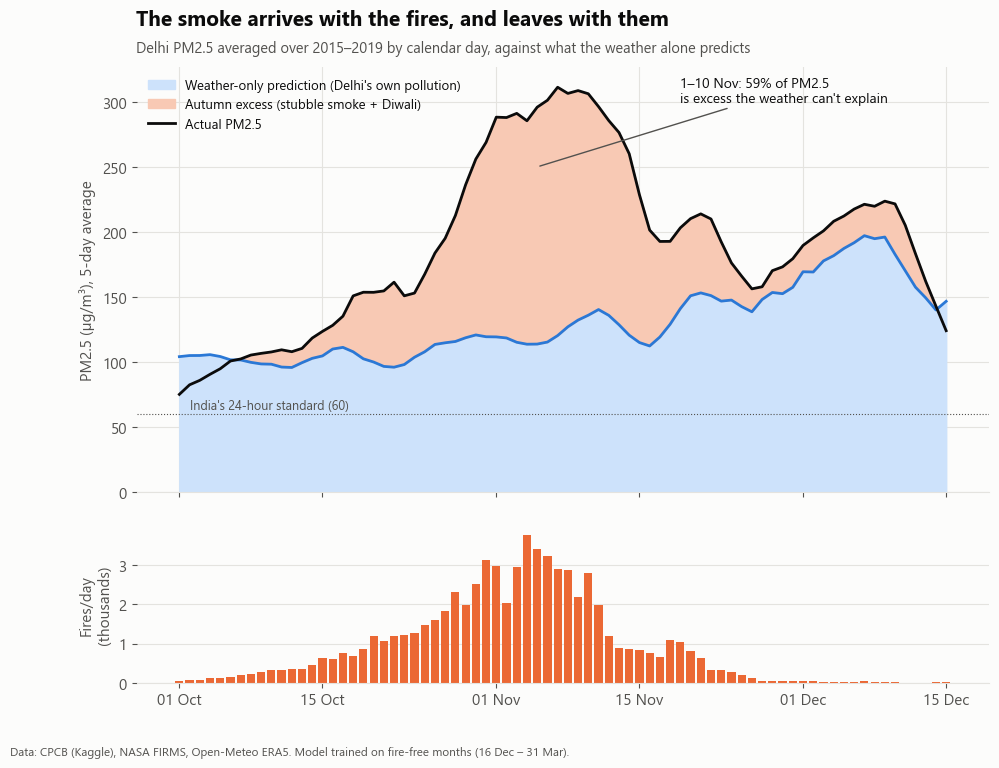

In [7]:
# Chart 3: the average day of the season (2015-2019), actual vs weather-only, with the fires below
by_day = season_window.groupby("md")[["pm25_city", "predicted", "fire_count"]].mean()

# turn month-day numbers (1105) into dates in one year, so the x axis can show "05 Nov"
dates = []
for md in by_day.index:
    dates.append(pd.Timestamp(year=2019, month=md // 100, day=md % 100))
by_day.index = pd.DatetimeIndex(dates)
smooth = by_day.rolling(5, center=True, min_periods=3).mean()     # 5-day average

fig, (ax, ax_fires) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1.1], "hspace": 0.12})
ax.fill_between(smooth.index, 0, smooth["predicted"], color=BLUE_LIGHT,
                label="Weather-only prediction (Delhi's own pollution)")
ax.fill_between(smooth.index, smooth["predicted"], smooth["pm25_city"], where=smooth["pm25_city"] > smooth["predicted"],
                color=ORANGE_LIGHT, label="Autumn excess (stubble smoke + Diwali)")
ax.plot(smooth.index, smooth["predicted"], color=BLUE, lw=2)
ax.plot(smooth.index, smooth["pm25_city"], color=INK, lw=2, label="Actual PM2.5")
ax.axhline(60, color=INK_2, lw=0.8, ls=":")
ax.text(smooth.index[1], 64, "India's 24-hour standard (60)", fontsize=9, color=INK_2)

peak_share = check.loc["1–10 Nov", "excess share"]
ax.annotate(f"1–10 Nov: {peak_share} of PM2.5\nis excess the weather can't explain",
            xy=(pd.Timestamp("2019-11-05"), 250), xytext=(pd.Timestamp("2019-11-19"), 300), fontsize=10,
            arrowprops=dict(arrowstyle="-", color=INK_2))
ax.set_ylabel("PM2.5 (µg/m³), 5-day average")
ax.set_ylim(0, None)
ax.legend(loc="upper left", fontsize=9.5)
titles(ax, "The smoke arrives with the fires, and leaves with them",
       "Delhi PM2.5 averaged over 2015–2019 by calendar day, against what the weather alone predicts")

ax_fires.bar(by_day.index, by_day["fire_count"] / 1000, color=ORANGE, width=0.8)
ax_fires.set_ylabel("Fires/day\n(thousands)")
ax_fires.grid(axis="x", visible=False)
ax_fires.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
footnote(fig, "Data: CPCB (Kaggle), NASA FIRMS, Open-Meteo ERA5. Model trained on fire-free months (16 Dec – 31 Mar).", y=0.02)
save(fig, "03_weather_normalised.png")
plt.show()

## 4. The smoke fingerprint: it depends on the wind

If the excess really is smoke from Punjab and Haryana, it should be biggest when the wind blows *from*
there (north-west). The weather model already accounts for what NW winds normally do to Delhi's air in
winter, so any extra NW effect at the peak of burning season is smoke-specific. Early December, with no
fires, is the comparison.

In [8]:
def excess_by_wind(days):
    """Split days into thirds by how much of the day the wind blew from the north-west; average excess of each."""
    days = days.copy()
    wind_groups = ["Mostly other directions", "Mixed", "Mostly north-westerly"]
    days["wind"] = pd.qcut(days["nw_wind_share"], 3, labels=wind_groups)
    return days.groupby("wind", observed=True)["excess"].mean()


peak_days = season_window[(season_window["md"] >= 1021) & (season_window["md"] <= 1115)]
december_days = season_window[(season_window["md"] >= 1201) & (season_window["md"] <= 1215)]
fingerprint = pd.DataFrame({
    "Peak burning (21 Oct – 15 Nov)": excess_by_wind(peak_days),
    "Early December (no fires)": excess_by_wind(december_days),
})
display(fingerprint.T)

wind,Mostly other directions,Mixed,Mostly north-westerly
Peak burning (21 Oct – 15 Nov),91.2,152.1,152.4
Early December (no fires),33.6,22.8,3.9


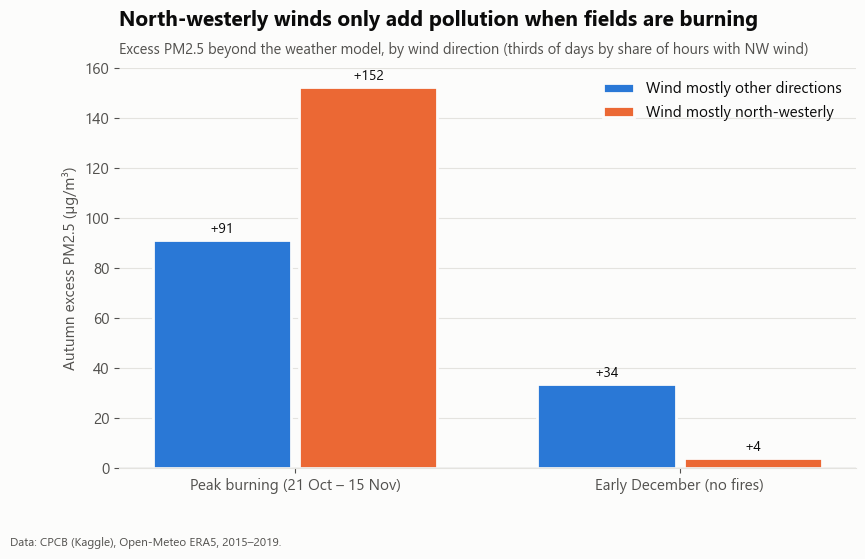

In [9]:
# Chart 4: excess on mostly-NW-wind days vs other days, at peak burning and in December
x = np.arange(2)
bar_width = 0.36

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for k, (group, colour) in enumerate([("Mostly other directions", BLUE), ("Mostly north-westerly", ORANGE)]):
    values = fingerprint.loc[group].values
    positions = x + (k - 0.5) * (bar_width + 0.02)
    bars = ax.bar(positions, values, bar_width, color=colour, label=f"Wind {group.lower()}", edgecolor="#fcfcfb",
                  linewidth=2)
    labels = []
    for value in values:
        labels.append(f"{value:+.0f}")
    ax.bar_label(bars, labels=labels, padding=3, fontsize=10)

ax.axhline(0, color=INK_2, lw=0.8)
ax.set_xticks(x, fingerprint.columns)
ax.set_ylabel("Autumn excess PM2.5 (µg/m³)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
titles(ax, "North-westerly winds only add pollution when fields are burning",
       "Excess PM2.5 beyond the weather model, by wind direction (thirds of days by share of hours with NW wind)")
footnote(fig, "Data: CPCB (Kaggle), Open-Meteo ERA5, 2015–2019.", y=-0.04)
save(fig, "04_wind_fingerprint.png")
plt.show()

## 5. Diwali: one of the worst nights of every year, but a short spike

In [10]:
# hourly PM2.5 from 2 days before to 4 days after each Diwali, lined up so hour 0 = midnight before Diwali
windows = []
for diwali_day in DIWALI:
    start = diwali_day - pd.Timedelta(days=2)
    end = diwali_day + pd.Timedelta(days=4)
    window = hourly[(hourly["datetime"] >= start) & (hourly["datetime"] < end)].copy()
    window["hours"] = (window["datetime"] - diwali_day) / pd.Timedelta(hours=1)
    window["year"] = diwali_day.year
    windows.append(window)
events = pd.concat(windows)
mean_curve = events.groupby("hours")["pm25"].mean()

# the worst hour of each Diwali night (6 pm to 6 am)
night = events[(events["hours"] >= 18) & (events["hours"] < 30)]
night_peaks = night.groupby("year")["pm25"].max()

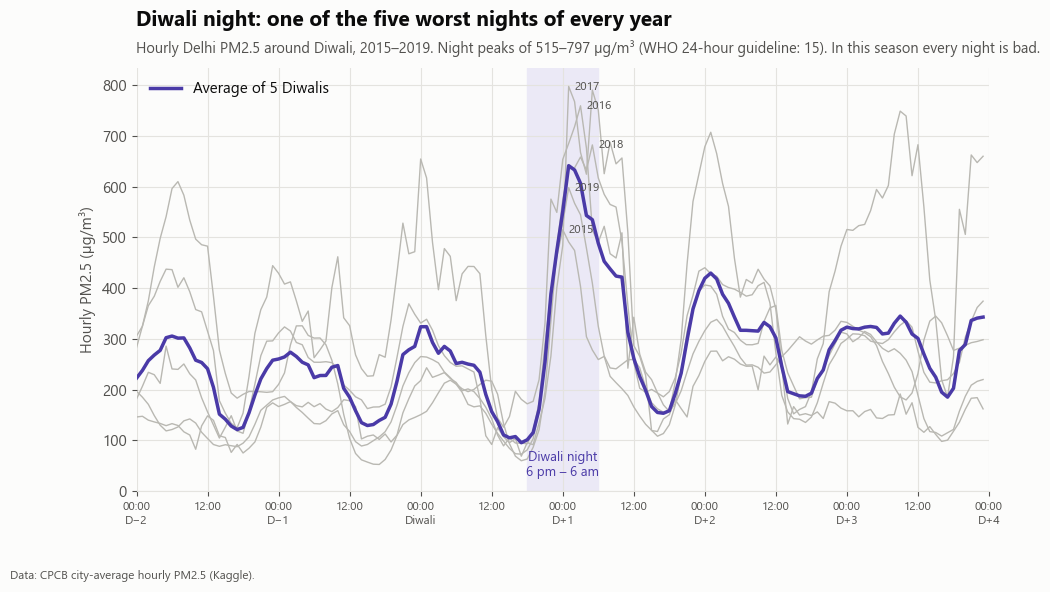

,night peak (µg/m³),rank among the year's daily peaks
Diwali,,
2015-11-11,514.9,2
2016-10-30,759.3,5
2017-10-19,797.5,2
2018-11-07,682.2,1
2019-10-27,597.9,3


In [11]:
# Chart 5: the five Diwalis hour by hour, and their average
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axvspan(18, 30, color="#ebe9f6", zorder=0)
ax.text(24, 30, "Diwali night\n6 pm – 6 am", ha="center", fontsize=9.5, color=VIOLET)
for year, rows in events.groupby("year"):
    ax.plot(rows["hours"], rows["pm25"], color=NEUTRAL, lw=1)
    night_rows = rows[(rows["hours"] >= 18) & (rows["hours"] < 30)]
    worst = night_rows.loc[night_rows["pm25"].idxmax()]
    ax.text(worst["hours"] + 1, worst["pm25"], str(year), fontsize=8.5, color=INK_2, va="center")
ax.plot(mean_curve.index, mean_curve.values, color=VIOLET, lw=2.5, label="Average of 5 Diwalis")

# x axis: midnight of each day (with its name) and noon
day_names = ["D−2", "D−1", "Diwali", "D+1", "D+2", "D+3", "D+4"]
tick_positions = list(range(-48, 97, 12))
tick_labels = []
for hour in tick_positions:
    if hour % 24 == 0:
        tick_labels.append(f"00:00\n{day_names[(hour + 48) // 24]}")
    else:
        tick_labels.append("12:00")
ax.set_xticks(tick_positions, tick_labels, fontsize=8.5)

ax.set_xlim(-48, 96)
ax.set_ylim(0, None)
ax.set_ylabel("Hourly PM2.5 (µg/m³)")
ax.legend(loc="upper left")
titles(ax, "Diwali night: one of the five worst nights of every year",
       f"Hourly Delhi PM2.5 around Diwali, 2015–2019. Night peaks of {night_peaks.min():.0f}–{night_peaks.max():.0f} µg/m³ "
       "(WHO 24-hour guideline: 15). In this season every night is bad.")
footnote(fig, "Data: CPCB city-average hourly PM2.5 (Kaggle).", y=-0.05)
save(fig, "05_diwali_hourly.png")
plt.show()

# how Diwali night ranks among each year's 365 daily peaks
ranks = []
for diwali_day in DIWALI:
    year_rows = hourly[hourly["datetime"].dt.year == diwali_day.year].dropna()
    daily_peak = year_rows.groupby(year_rows["datetime"].dt.date)["pm25"].max()
    diwali_peak = night_peaks[diwali_day.year]
    worse_days = (daily_peak > diwali_peak).sum()
    ranks.append({
        "Diwali": diwali_day.date(),
        "night peak (µg/m³)": diwali_peak,
        "rank among the year's daily peaks": int(worse_days) + 1,
    })
pd.DataFrame(ranks).set_index("Diwali")

**How big is Diwali's share?** Pollution keeps climbing for days after Diwali, because Diwali falls
inside the burning season. So the comparison is the weather-normalised excess on Diwali day and the
day after, against the excess on the three days before *and* after.

In [12]:
excess_by_date = season_window.set_index("date")["excess"]


def excess_on(day):
    """The autumn excess on a given day (NaN if missing)."""
    return excess_by_date.get(day, np.nan)


bumps = []
for diwali_day in DIWALI:
    # typical excess on the 3 days before and the 3 days after (Diwali and the day after left out)
    nearby = []
    for k in [-3, -2, -1, 2, 3, 4]:
        nearby.append(excess_on(diwali_day + pd.Timedelta(days=k)))
    typical = np.nanmean(nearby)

    on_diwali = excess_on(diwali_day)
    day_after = excess_on(diwali_day + pd.Timedelta(days=1))
    bump = (on_diwali - typical) + (day_after - typical)
    bumps.append({
        "Diwali": diwali_day.date(),
        "excess on Diwali + next day": on_diwali + day_after,
        "typical excess around it (×2 days)": 2 * typical,
        "Diwali bump (µg/m³·days)": bump,
    })
bumps = pd.DataFrame(bumps).set_index("Diwali")
diwali_bump = bumps["Diwali bump (µg/m³·days)"].mean()
bumps

,excess on Diwali + next day,typical excess around it (×2 days),Diwali bump (µg/m³·days)
Diwali,,,
2015-11-11,264.8,220.4,44.4
2016-10-30,495.4,458.8,36.7
2017-10-19,369.0,83.2,285.8
2018-11-07,279.9,266.9,13.1
2019-10-27,343.2,276.8,66.3


## 6. The pollution budget

Adding it up for each winter (15 October – 28 February), how much of the total PM2.5 exposure comes
from each source?

In [13]:
budget = []
for i, season in enumerate(SEASONS):
    winter = daily[(daily["date"] >= f"{season}-10-15") & (daily["date"] <= f"{season + 1}-02-28")]
    total = winter["pm25_city"].mean() * len(winter)       # total exposure, µg/m³·days

    burning = season_window[(season_window["season"] == season) & (season_window["md"] >= 1015)
                            & (season_window["md"] <= 1130)]
    autumn_excess = burning["excess"].sum()
    diwali = bumps["Diwali bump (µg/m³·days)"].iloc[i]

    budget.append({
        "season": season,
        "Diwali": diwali / total,
        "Stubble-season smoke": (autumn_excess - diwali) / total,
        "Delhi's own pollution + weather": 1 - autumn_excess / total,
    })
budget = pd.DataFrame(budget).set_index("season")

# the peak smoke period: 1-10 November, without Diwali and the day after
early_nov = season_window[(season_window["md"] >= 1101) & (season_window["md"] <= 1110)]
early_nov = early_nov[~early_nov["date"].isin(DIWALI) & ~early_nov["date"].isin(DIWALI + pd.Timedelta(days=1))]
peak_smoke_share = early_nov["excess"].mean() / early_nov["pm25_city"].mean()

whole_winter = budget.mean()
peak_smoke = pd.Series({"Diwali": 0, "Stubble-season smoke": peak_smoke_share,
                        "Delhi's own pollution + weather": 1 - peak_smoke_share})
shares = pd.DataFrame({
    "Whole winter\n(15 Oct – 28 Feb)": whole_winter,
    "Peak smoke\n(1–10 Nov, excl. Diwali)": peak_smoke,
}).T
display((100 * budget).round(1))

,Diwali,Stubble-season smoke,Delhi's own pollution + weather
season,,,
2015,0.2,11.0,88.8
2016,0.1,17.7,82.2
2017,1.1,16.9,82.1
2018,0.1,12.0,87.9
2019,0.3,20.9,78.8


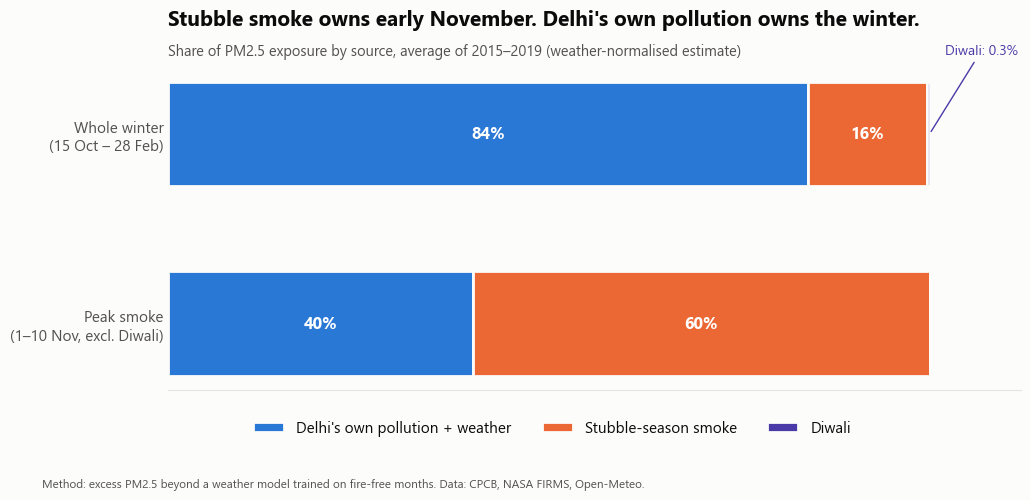

In [14]:
# Chart 6: the two budgets as 100% bars
parts = ["Delhi's own pollution + weather", "Stubble-season smoke", "Diwali"]
part_colours = {"Delhi's own pollution + weather": BLUE, "Stubble-season smoke": ORANGE, "Diwali": VIOLET}

fig, ax = plt.subplots(figsize=(11, 4.2))
left = np.zeros(len(shares))
for part in parts:
    values = shares[part].values
    ax.barh(range(len(shares)), values, left=left, color=part_colours[part], height=0.55, edgecolor="#fcfcfb",
            linewidth=2, label=part)
    for i in range(len(values)):
        if values[i] >= 0.06:        # only label the pieces that are wide enough
            ax.text(left[i] + values[i] / 2, i, f"{values[i]:.0%}", ha="center", va="center", color="white",
                    fontsize=12, fontweight="bold")
    left = left + values

diwali_share = shares.iloc[0]["Diwali"]
ax.annotate(f"Diwali: {diwali_share:.1%}", xy=(1.0, 0), xytext=(1.02, -0.42), fontsize=10, color=VIOLET,
            arrowprops=dict(arrowstyle="-", color=VIOLET))
ax.set_yticks(range(len(shares)), shares.index)
ax.tick_params(axis="y", length=0)
ax.invert_yaxis()
ax.set_xlim(0, 1.12)
ax.set_xticks([])
ax.grid(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.45, -0.05), ncol=3)
titles(ax, "Stubble smoke owns early November. Delhi's own pollution owns the winter.",
       "Share of PM2.5 exposure by source, average of 2015–2019 (weather-normalised estimate)")
footnote(fig, "Method: excess PM2.5 beyond a weather model trained on fire-free months. Data: CPCB, NASA FIRMS, Open-Meteo.", y=-0.12)
save(fig, "06_pollution_budget.png")
plt.show()

## 7. Robustness

The headline numbers shouldn't depend on one modelling choice. Each variant is re-run below.

In [15]:
def run_variant(y="pm25_city", train_mask=None, formula=None, gbm=False):
    """Re-run the weather normalisation with one choice changed, and return the key numbers."""
    target = daily[(daily["md"] >= 1001) & (daily["md"] <= 1215) & daily["season"].isin(SEASONS)].copy()

    if gbm:
        # gradient boosting instead of the regression
        columns = ["wind_kmh", "wind_u", "wind_v", "lmix", "lnight", "temp_c", "temp_range_c", "rh_pct", "rain_mm",
                   "season", "dow"]
        train_days = daily[((daily["md"] >= 1216) | (daily["md"] <= 331)) & ~covid & daily[y].notna()]
        booster = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_leaf_nodes=8,
                                                min_samples_leaf=30, random_state=0)
        booster.fit(train_days[columns], np.log(train_days[y]))
        residuals = np.log(train_days[y]) - booster.predict(train_days[columns])
        smear_factor = np.mean(np.exp(residuals))
        target["predicted"] = np.exp(booster.predict(target[columns])) * smear_factor
    else:
        variant_model, smear_factor, _ = weather_model(y, train_mask, formula)
        target["predicted"] = np.exp(variant_model.predict(target)) * smear_factor
    target["excess"] = target[y] - target["predicted"]

    def between(start, end):
        """The target days between two month-days, e.g. between(1101, 1110) = 1-10 November."""
        return target[(target["md"] >= start) & (target["md"] <= end)]

    burning = between(1015, 1130)
    return {
        "early Oct excess (should be ~0)": between(1001, 1010)["excess"].mean(),
        "15 Oct–30 Nov excess": burning["excess"].mean(),
        "share of PM2.5": f"{burning['excess'].mean() / burning[y].mean():.0%}",
        "1–10 Nov excess": between(1101, 1110)["excess"].mean(),
        "early Dec excess (should be ~0)": between(1201, 1215)["excess"].mean(),
    }


jan_to_mar = (daily["md"] >= 101) & (daily["md"] <= 331)
pd.DataFrame({
    "Main model": run_variant(),
    "10 long-running stations only": run_variant("pm25_core10"),
    "Train on Jan–Mar only": run_variant(train_mask=jan_to_mar),
    "Season as a trend, not levels": run_variant(formula=f"np.log(pm25_city) ~ {WEATHER_TERMS} + season"),
    "Gradient boosting model": run_variant(gbm=True),
}).T

,early Oct excess (should be ~0),15 Oct–30 Nov excess,share of PM2.5,1–10 Nov excess,early Dec excess (should be ~0)
Main model,-6.7,91.0,42%,177.6,20.2
10 long-running stations only,-14.2,86.5,40%,170.3,22.7
Train on Jan–Mar only,-3.8,92.8,43%,179.9,24.3
"Season as a trend, not levels",-4.5,92.5,43%,181.2,23.3
Gradient boosting model,-20.2,99.1,46%,184.9,25.8


Every variant puts the autumn excess at **85–100 µg/m³, or 40–46% of PM2.5, from mid-October to the end
of November**. Early October stays within 20 µg/m³ of zero in every case. Early December sits at +20 to +26, which
suggests the model slightly under-predicts in late autumn. Subtracting that bias from the main estimate
gives a lower bound of about a third of PM2.5.

## Limitations

- **The excess is "autumn-only pollution", not proven stubble smoke.** Its timing matches the fires, and
  it depends on wind from the fire region, but other autumn-only sources (Dussehra, regional burning
  outside Punjab and Haryana) are mixed in.
- **The PM2.5 data ends in mid-2020**, so it can't show whether Delhi's air improved as fire detections fell
  from 2021 to 2025. Satellite counts may also understate burning if farmers burn after the satellite passes.
- **Five seasons is a small sample.** Year-to-year numbers vary (Diwali's bump ranges from 13 to 286 µg/m³·days).
- **The weather comes from one grid point** (ERA5 reanalysis at central Delhi), not local measurements.

In [16]:
# save the daily results for other tools (dashboards, the README charts)
columns = ["date", "pm25_city", "predicted", "excess", "fire_count", "nw_wind_share", "mixing_height_m"]
season_window[columns].to_csv(PROC / "weather_normalised_daily.csv", index=False)